In [3]:
import cv2
import os

# 1. Tạo thư mục để chứa ảnh xuất ra
output_folder = 'dataset_images'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# 2. Đọc file video
video_path = r'C:\Users\Admin\OneDrive\Máy tính\Simulation and Machine Learning\Video\video.mp4'
cap = cv2.VideoCapture(video_path)

frame_count = 0
saved_count = 0

# Cứ cách bao nhiêu frame thì lưu 1 ảnh? (Nếu video 30fps, cách 3 frame lưu 1 ảnh sẽ tránh bị trùng lặp quá nhiều)
frame_skip = 3 

print("Đang tiến hành cắt ảnh...")

while True:
    ret, frame = cap.read()
    if not ret:
        break # Kết thúc video

    # 3. Lưu ảnh
    if frame_count % frame_skip == 0:
        image_name = f"{output_folder}/frame_{saved_count:04d}.jpg"
        cv2.imwrite(image_name, frame)
        saved_count += 1
        
    frame_count += 1

cap.release()
print(f"Xong! Đã cắt thành công {saved_count} bức ảnh vào thư mục '{output_folder}'.")

Đang tiến hành cắt ảnh...
Xong! Đã cắt thành công 250 bức ảnh vào thư mục 'dataset_images'.


In [15]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [25]:
pip install streamlit


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Đang xuất dữ liệu và vẽ đồ thị...


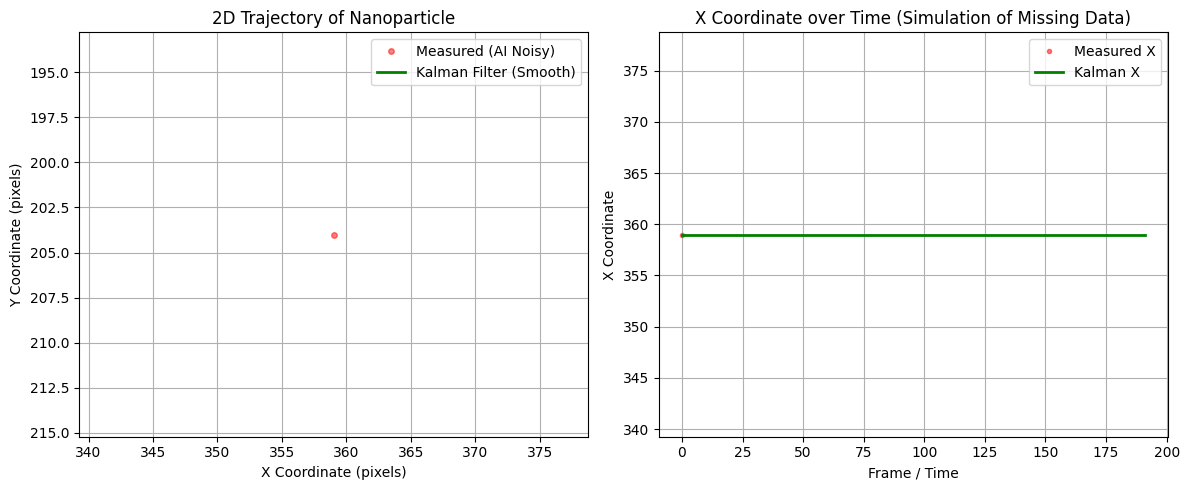

In [23]:
import cv2
import numpy as np
import math
import random
import csv
import matplotlib.pyplot as plt

# ==========================================
# PHẦN 1: LỚP TOÁN HỌC KALMAN FILTER
# ==========================================
class KalmanFilter:
    def __init__(self):
        self.dt = 1.0 
        self.X = np.zeros((4, 1))
        self.initialized = False 
        
        self.A = np.array([[1, 0, self.dt, 0],
                           [0, 1, 0, self.dt],
                           [0, 0, 1, 0],
                           [0, 0, 0, 1]])
        
        self.H = np.array([[1, 0, 0, 0],
                           [0, 1, 0, 0]])
        
        self.P = np.eye(4) * 1000
        self.Q = np.eye(4) * 0.1
        self.R = np.eye(2) * 5.0
        
    def predict(self):
        self.X = np.dot(self.A, self.X)
        self.P = np.dot(np.dot(self.A, self.P), self.A.T) + self.Q
        return int(self.X[0, 0]), int(self.X[1, 0])
        
    def update(self, z):
        Z = np.array([[z[0]], [z[1]]])
        S = np.dot(self.H, np.dot(self.P, self.H.T)) + self.R
        K = np.dot(np.dot(self.P, self.H.T), np.linalg.inv(S))
        Y = Z - np.dot(self.H, self.X)
        self.X = self.X + np.dot(K, Y)
        I = np.eye(self.H.shape[1])
        self.P = np.dot((I - np.dot(K, self.H)), self.P)

# ==========================================
# PHẦN 2: CHƯƠNG TRÌNH CHÍNH (GIAO DIỆN FANCY)
# ==========================================
def main():
    video_path = r'C:\Users\Admin\OneDrive\Máy tính\Simulation and Machine Learning\Video\video.mp4'
    cap = cv2.VideoCapture(video_path)
    
    ret, frame = cap.read()
    if not ret:
        print("Không đọc được video!")
        return
    
    bbox = cv2.selectROI("Lock-on Target", frame, fromCenter=False, showCrosshair=True)
    cv2.destroyWindow("Lock-on Target")
    
    init_x = int(bbox[0] + bbox[2] / 2)
    init_y = int(bbox[1] + bbox[3] / 2)

    kf = KalmanFilter()
    kf.X[0, 0] = init_x
    kf.X[1, 0] = init_y
    kf.initialized = True
    
    trajectory_kalman = [(init_x, init_y)]
    trajectory_measured = [(init_x, init_y)]
    frames = [0]
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        frame_count += 1
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        
        _, thresh = cv2.threshold(blurred, 150, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        pred_x, pred_y = kf.predict()
        best_match_x, best_match_y = None, None
        min_dist = 40 
        
        for cnt in contours:
            if cv2.contourArea(cnt) > 2: 
                M = cv2.moments(cnt)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                    dist = math.hypot(cx - pred_x, cy - pred_y)
                    if dist < min_dist:
                        min_dist = dist
                        best_match_x, best_match_y = cx, cy

        # --- LOGIC CẬP NHẬT TRẠNG THÁI ---
        tracking_status = "LOCKED"
        status_color = (0, 255, 0) # Xanh lá
        
        if best_match_x is not None and random.random() > 0.3:
            kf.update((best_match_x, best_match_y))
            trajectory_measured.append((best_match_x, best_match_y))
        else:
            trajectory_measured.append((np.nan, np.nan)) 
            tracking_status = "PREDICTING (AI LOST)"
            status_color = (0, 165, 255) # Màu cam cảnh báo

        final_x, final_y = int(kf.X[0, 0]), int(kf.X[1, 0])
        trajectory_kalman.append((final_x, final_y))
        frames.append(frame_count)
        
        # Lấy vận tốc từ ma trận Kalman (v_x và v_y)
        vx, vy = kf.X[2, 0], kf.X[3, 0]
        speed = math.hypot(vx, vy)

        # ==========================================
        # KHÚC NÀY LÀ VẼ GIAO DIỆN (UI/UX)
        # ==========================================
        
        # 1. Vẽ đuôi sao chổi (Chỉ giữ 30 điểm gần nhất, mờ và nhỏ dần)
        tail_length = 30
        recent_traj = trajectory_kalman[-tail_length:]
        for i in range(1, len(recent_traj)):
            # Tính độ dày của line (càng cũ càng mỏng)
            thickness = int(max(1, 4 * (i / tail_length)))
            cv2.line(frame, recent_traj[i-1], recent_traj[i], status_color, thickness)

        # 2. Vẽ Tâm ngắm (Crosshair)
        length = 15
        cv2.line(frame, (final_x - length, final_y), (final_x + length, final_y), status_color, 2)
        cv2.line(frame, (final_x, final_y - length), (final_x, final_y + length), status_color, 2)
        cv2.circle(frame, (final_x, final_y), 8, status_color, 1)

        # 3. Vẽ Bảng điều khiển HUD
        # Tạo khung nền đen
        cv2.rectangle(frame, (10, 10), (360, 130), (0, 0, 0), -1)
        cv2.rectangle(frame, (10, 10), (360, 130), (255, 255, 255), 1) # Viền trắng
        
        # Ghi chữ lên bảng
        cv2.putText(frame, "NANO-TRACKER PRO v1.0", (20, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
        cv2.putText(frame, f"STATUS: {tracking_status}", (20, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.6, status_color, 2)
        cv2.putText(frame, f"SPEED:  {speed:.2f} px/frame", (20, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
        cv2.putText(frame, f"COORD:  X={final_x} | Y={final_y}", (20, 115), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

        cv2.imshow('Simulation: Nanoparticle Tracking', frame)
        
        if cv2.waitKey(40) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

    print("Đang xuất dữ liệu và vẽ đồ thị...")

    # Xuất CSV
    with open('tracking_data.csv', mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Frame', 'Measured_X', 'Measured_Y', 'Kalman_X', 'Kalman_Y'])
        for i in range(len(frames)):
            writer.writerow([frames[i], trajectory_measured[i][0], trajectory_measured[i][1], 
                             trajectory_kalman[i][0], trajectory_kalman[i][1]])
                             
    # Vẽ đồ thị (Giữ nguyên như cũ)
    meas_x = [p[0] for p in trajectory_measured]
    meas_y = [p[1] for p in trajectory_measured]
    kal_x = [p[0] for p in trajectory_kalman]
    kal_y = [p[1] for p in trajectory_kalman]

    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(meas_x, meas_y, 'ro', label='Measured (AI Noisy)', markersize=4, alpha=0.5)
    plt.plot(kal_x, kal_y, 'g-', label='Kalman Filter (Smooth)', linewidth=2)
    plt.title('2D Trajectory of Nanoparticle')
    plt.xlabel('X Coordinate (pixels)')
    plt.ylabel('Y Coordinate (pixels)')
    plt.legend()
    plt.grid(True)
    plt.gca().invert_yaxis()

    plt.subplot(1, 2, 2)
    plt.plot(frames, meas_x, 'ro', label='Measured X', markersize=3, alpha=0.5)
    plt.plot(frames, kal_x, 'g-', label='Kalman X', linewidth=2)
    plt.title('X Coordinate over Time (Simulation of Missing Data)')
    plt.xlabel('Frame / Time')
    plt.ylabel('X Coordinate')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [1]:
import streamlit as st
import cv2
import numpy as np
import math
import random
import matplotlib.pyplot as plt
import tempfile

# ==========================================
# CẤU HÌNH TRANG WEB
# ==========================================
st.set_page_config(page_title="NTA Web App Pro", layout="wide", page_icon="🔬")
st.title("🔬 Ứng Dụng NTA: Phân Tích & Theo Dõi Hạt Nano")
st.markdown("Phần mềm mô phỏng thuật toán **Kalman Filter** sửa lỗi nhận diện AI trong môi trường vi lưu chất.")

# ==========================================
# CÁC HẰNG SỐ VẬT LÝ
# ==========================================
PIXEL_TO_NM = 50.0       
FPS = 30.0               
DT = 1.0 / FPS           
KB = 1.380649e-23        
TEMP_K = 298.15          
VISCOSITY = 0.89e-3      

# ==========================================
# LỚP TOÁN HỌC KALMAN FILTER
# ==========================================
class KalmanFilter:
    def __init__(self):
        self.dt = 1.0 
        self.X = np.zeros((4, 1))
        self.A = np.array([[1, 0, self.dt, 0], [0, 1, 0, self.dt], [0, 0, 1, 0], [0, 0, 0, 1]])
        self.H = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])
        self.P = np.eye(4) * 1000
        self.Q = np.eye(4) * 0.1
        self.R = np.eye(2) * 5.0
        
    def predict(self):
        self.X = np.dot(self.A, self.X)
        self.P = np.dot(np.dot(self.A, self.P), self.A.T) + self.Q
        return float(self.X[0, 0]), float(self.X[1, 0])
        
    def update(self, z):
        Z = np.array([[z[0]], [z[1]]])
        S = np.dot(self.H, np.dot(self.P, self.H.T)) + self.R
        K = np.dot(np.dot(self.P, self.H.T), np.linalg.inv(S))
        Y = Z - np.dot(self.H, self.X)
        self.X = self.X + np.dot(K, Y)
        I = np.eye(self.H.shape[1])
        self.P = np.dot((I - np.dot(K, self.H)), self.P)

# ==========================================
# GIAO DIỆN ĐIỀU KHIỂN BÊN TRÁI (SIDEBAR)
# ==========================================
st.sidebar.header("⚙️ Cài đặt Hệ thống")
uploaded_video = st.sidebar.file_uploader("1. Tải video NTA (mp4)", type=['mp4'])
threshold_val = st.sidebar.slider("2. Độ nhạy sáng (Threshold)", 50, 250, 150)
sensor_error = st.sidebar.slider("3. Tỷ lệ lỗi AI giả lập (%)", 0, 80, 30)

if uploaded_video is not None:
    # Lưu video tạm thời để OpenCV có thể đọc
    tfile = tempfile.NamedTemporaryFile(delete=False)
    tfile.write(uploaded_video.read())
    video_path = tfile.name

    if st.sidebar.button("🚀 BẮT ĐẦU PHÂN TÍCH"):
        cap = cv2.VideoCapture(video_path)
        
        # Tạo khung chứa video trên Web
        video_placeholder = st.empty()
        
        # Các cột hiển thị thông số Real-time
        col1, col2, col3 = st.columns(3)
        status_text = col1.empty()
        size_text = col2.empty()
        coord_text = col3.empty()
        
        # --- Khởi tạo Auto-Lock ---
        ret, frame = cap.read()
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        _, thresh = cv2.threshold(blurred, threshold_val, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if not contours:
            st.error("Không tìm thấy hạt nào! Hãy giảm độ nhạy sáng xuống.")
            st.stop()
            
        largest_contour = max(contours, key=cv2.contourArea)
        M = cv2.moments(largest_contour)
        init_x = float(M["m10"] / M["m00"])
        init_y = float(M["m01"] / M["m00"])

        kf = KalmanFilter()
        kf.X[0, 0] = init_x
        kf.X[1, 0] = init_y
        
        trajectory_kalman = [(init_x, init_y)]
        trajectory_measured = [(init_x, init_y)]
        frames, size_array, msd_array = [0], [0], [0]
        
        frame_count = 0
        start_x, start_y = init_x, init_y
        
        # --- Vòng lặp Xử lý Video ---
        while True:
            ret, frame = cap.read()
            if not ret:
                break
                
            frame_count += 1
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            blurred = cv2.GaussianBlur(gray, (5, 5), 0)
            _, thresh = cv2.threshold(blurred, threshold_val, 255, cv2.THRESH_BINARY)
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            pred_x, pred_y = kf.predict()
            best_match_x, best_match_y = None, None
            min_dist = 40 
            
            for cnt in contours:
                if cv2.contourArea(cnt) > 2: 
                    M = cv2.moments(cnt)
                    if M["m00"] != 0:
                        cx = float(M["m10"] / M["m00"])
                        cy = float(M["m01"] / M["m00"])
                        dist = math.hypot(cx - pred_x, cy - pred_y)
                        if dist < min_dist:
                            min_dist = dist
                            best_match_x, best_match_y = cx, cy

            tracking_status = "LOCKED"
            status_color = (0, 255, 0)
            
            # Mô phỏng lỗi
            if best_match_x is not None and random.random() > (sensor_error / 100.0):
                kf.update((best_match_x, best_match_y))
                trajectory_measured.append((best_match_x, best_match_y))
            else:
                trajectory_measured.append((np.nan, np.nan)) 
                tracking_status = "PREDICTING (AI LOST)"
                status_color = (255, 165, 0)

            final_x, final_y = float(kf.X[0, 0]), float(kf.X[1, 0])
            trajectory_kalman.append((final_x, final_y))
            frames.append(frame_count)
            
            # --- Tính Vật Lý ---
            sd_meters = ((final_x - start_x)**2 + (final_y - start_y)**2) * (PIXEL_TO_NM * 1e-9)**2
            time_elapsed = frame_count * DT
            msd = sd_meters / time_elapsed 
            msd_array.append(msd)
            
            D = msd / 4.0 if msd > 0 else 1e-15
            d_h_meters = (KB * TEMP_K) / (3.0 * math.pi * VISCOSITY * D)
            d_h_nm = min(max(d_h_meters * 1e9, 10), 1000) 
            size_array.append(d_h_nm)

            # --- Vẽ UI ---
            tail_length = 30
            recent_traj = trajectory_kalman[-tail_length:]
            for i in range(1, len(recent_traj)):
                thickness = int(max(1, 4 * (i / tail_length)))
                pt1 = (int(recent_traj[i-1][0]), int(recent_traj[i-1][1]))
                pt2 = (int(recent_traj[i][0]), int(recent_traj[i][1]))
                cv2.line(frame, pt1, pt2, status_color, thickness)

            draw_x, draw_y = int(final_x), int(final_y)
            length = 15
            cv2.line(frame, (draw_x - length, draw_y), (draw_x + length, draw_y), status_color, 2)
            cv2.line(frame, (draw_x, draw_y - length), (draw_x, draw_y + length), status_color, 2)
            cv2.circle(frame, (draw_x, draw_y), 8, status_color, 1)

            # Cập nhật lên Web
            video_placeholder.image(frame, channels="BGR", use_container_width=True)
            status_text.metric("Trạng thái", tracking_status)
            size_text.metric("Kích thước hạt (Ước tính)", f"{d_h_nm:.1f} nm")
            coord_text.metric("Tọa độ hiện tại", f"X: {draw_x} | Y: {draw_y}")

        cap.release()
        st.success("✅ Đã hoàn thành Tracking! Đang vẽ đồ thị báo cáo...")

        # ==========================================
        # XUẤT ĐỒ THỊ BÁO CÁO LÊN WEB
        # ==========================================
        st.markdown("---")
        st.subheader("📊 Báo cáo Khoa học (Physics Report)")
        
        meas_x = [p[0] for p in trajectory_measured]
        kal_x = [p[0] for p in trajectory_kalman]
        time_sec = [f * DT for f in frames]

        fig, axs = plt.subplots(1, 2, figsize=(15, 5))
        
        axs[0].plot(frames, meas_x, 'ro', label='AI Sensor (Lỗi)', alpha=0.4)
        axs[0].plot(frames, kal_x, 'g-', label='Kalman Filter (Đã sửa)', linewidth=2)
        axs[0].set_title("Nội suy và sửa lỗi (Trục X)")
        axs[0].set_xlabel("Frames")
        axs[0].set_ylabel("Tọa độ X")
        axs[0].legend()
        axs[0].grid(True)

        axs[1].plot(time_sec[10:], size_array[10:], 'm-', linewidth=2)
        final_size = np.mean(size_array[-30:]) if len(size_array) > 30 else size_array[-1]
        axs[1].axhline(y=final_size, color='k', linestyle='--', label=f'Kết quả cuối: {final_size:.1f} nm')
        axs[1].set_title("Ước lượng kích thước hạt qua thời gian")
        axs[1].set_xlabel("Thời gian (giây)")
        axs[1].set_ylabel("Kích thước (nm)")
        axs[1].legend()
        axs[1].grid(True)

        st.pyplot(fig)
else:
    st.info("👈 Hãy tải một đoạn video lên từ menu bên trái để bắt đầu.")

2026-03-30 13:52:25.362 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 13:52:25.362 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 13:52:25.806 
  command:

    streamlit run C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-30 13:52:25.807 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 13:52:25.807 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 13:52:25.807 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 1